In [7]:
using DataFrames
using CSV
using Plots
using LinearAlgebra

In [1]:
module ME_coupled
    include("ME_disperser_pool.jl")
end

Main.ME_coupled

In [50]:
## first test with no movement, to check the same result

# Define parameters dictionary
fem_m0 = 2
fem_w0 = 2
male_m0 = 2
male_w0 = 3
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
rho = 0#.1  # rate visit the households
tau = 0#.1  # rate leave the households
phi = 0.85 # wolbachia fitness effect on birth rate

K = 30
d = 12/100
k = 0.3
h = 0.19*100^k
b = 0.54
H = 100
u = 1
v = 1

t_start = 0
t_end = 1000   # start time and end time (days) of simulation

states = ME_coupled.state_space(K)
n_states = length(states)
result_length = length(t_start:t_end)
num_simulations = 1000

parameters = Dict(           # dictionary of parameters
    :fem_m0 => fem_m0,
    :male_m0 => male_m0,
    :fem_w0 => fem_w0,
    :male_w0 => male_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :n_states => n_states,
    :seed => 1234,
    :delta_rel => 100,
    :rel_size => 0,
)

Dict{Symbol, Real} with 23 entries:
  :b        => 0.54
  :rel_size => 0
  :m_free0  => 0
  :rho      => 0
  :t_start  => 0
  :h        => 0.756404
  :male_w0  => 3
  :fem_m0   => 2
  :K        => 30
  :n_states => 496
  :phi      => 0.85
  :fem_w0   => 2
  :d        => 0.12
  :k        => 0.3
  :v        => 1
  :u        => 1
  :male_m0  => 2
  :tau      => 0
  :t_end    => 1000
  ⋮         => ⋮

In [51]:
# Add worker processes
using Distributed

# remove any workers hanging around e.g. after code crashes
if length(workers()) > 1
    rmprocs(workers())
end

addprocs(6)  # Adjust the number based on your system's cores

@everywhere using SharedArrays   # Load the SharedArrays package on all worker processes

# Define your module with the function to be run in parallel
@everywhere module male_female_coupled
    include("SSA_Wolb_male_fem_move.jl")  # Assuming SSA_simple.jl defines a function named `gillespie`
end

# Define SharedArrays to store the results
m_results = SharedArray{Float64}(result_length, num_simulations)
w_results = SharedArray{Float64}(result_length, num_simulations)

free_m_results = SharedArray{Float64}(result_length, num_simulations)
free_w_results = SharedArray{Float64}(result_length, num_simulations)

# can't store results for household distributions as shared arrays
#num_house_results = SharedArray{Int64}(result_length*n_states, num_simulations)
#key_house_results = SharedArray{Tuple{Int, Int}}(result_length*n_states, num_simulations)

# Run the simulations in parallel; @time just times the whole block, @sync ensures all 
# processes are done before moving on
@time begin
    @sync @distributed for i in 1:num_simulations
        println("Starting simulation $i of $num_simulations")
        m_vec, w_vec = male_female_coupled.gillespie(parameters)
        m_results[:, i] = m_vec
        w_results[:, i] = w_vec
        #free_m_results[:, i] = free_m_vec
        #free_w_results[:, i] = free_w_vec
        
        println("Finished simulation $i of $num_simulations")
    end
end

using Statistics

Mss = mean(m_results, dims=2)
Wss = mean(w_results, dims=2)

rmprocs(workers())  # Remove the worker processes

Task (done) @0x000001d90d089560

In [4]:
# Create a new array to store the filtered results
filtered_m_results = []

# Loop through each column and check for zeros before the 100th index
for i in 1:size(m_results, 2)
    if !any(m_results[:, i] .== 0)
        push!(filtered_m_results, m_results[:, i])
    end
end

# Convert the filtered results to a matrix
filtered_m_results = hcat(filtered_m_results...)

println("Filtered m_results:")
println(filtered_m_results)
println(length(filtered_m_results))

Filtered m_results:
[400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 400.0 4

Excessive output truncated after 524293 bytes.

 139.0 139.0 99.0 108.0 132.0 100.0 229.0 105.0 160.0 100.0 152.0 92.0 151.0 243.0 118.0 149.0 154.0 108.0 117.0 120.0 234.0 109.0 178.0 131.0 159.0 82.0 111.0 117.0 209.0 173.0 115.0 202.0 171.0 125.0 84.0 147.0 224.0 143.0 153.0 207.0 194.0 252.0 204.0 225.0 149.0 81.0 167.0 70.0 62.0 168.0 144.0 118.0 140.0 140.0 249.0 251.0 106.0 133.0 129.0 142.0 96.0 204.0 133.0 225.0 176.0 154.0 102.0 118.0 152.0 90.0 158.0 122.0 99.0 171.0 94.0 236.0 139.0 187.0 117.0 182.0 165.0 212.0 111.0 76.0 82.0 99.0 149.0 85.0 242.0 63.0 118.0 221.0 156.0 130.0 220.0 151.0 148.0 134.0 228.0 205.0 207.0 185.0 158.0 121.0 85.0 144.0 176.0 196.0 149.0 76.0 96.0 63.0 193.0 83.0 113.0 153.0 180.0 135.0 178.0 139.0 142.0 103.0 125.0 109.0 124.0 98.0 66.0 53.0 181.0 75.0 163.0 92.0 216.0 75.0 215.0 99.0 81.0 244.0 189.0 114.0 101.0 139.0 133.0 105.0 170.0 165.0 222.0 165.0 118.0 71.0 127.0 89.0 123.0 172.0 148.0 104.0 135.0 105.0 101.0 115.0 71.0 157.0 112.0 150.0 143.0 129.0 117.0 145.0 156.0 111.0 56.0 139.0 

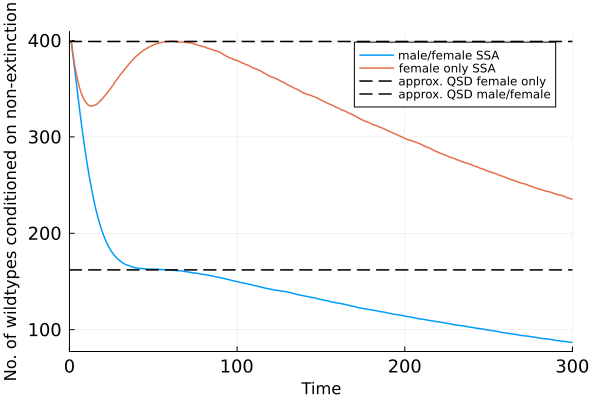

In [82]:
using Plots
using Statistics

# Assuming filtered_m_results and filtered_m_results_f are already defined
cond_ext_m = mean(filtered_m_results, dims=2)
cond_ext_mf = mean(filtered_m_results_f, dims=2)

# Compute the numerical derivative
gradient_m = diff(cond_ext_m[1:300])
gradient_mf = diff(cond_ext_mf[1:300] * 2)

# Define a threshold for "close to zero"
threshold = 1e-1

# Find the indices where the gradient is close to zero
indices_m = findall(abs.(gradient_m) .< threshold)
indices_mf = findall(abs.(gradient_mf) .< threshold)

# Print the indices
println("Indices where the gradient of cond_ext_m is close to zero: ", indices_m)
println("Indices where the gradient of cond_ext_mf is close to zero: ", indices_mf)

# Plot the data
p = plot(cond_ext_m[1:300], label="male/female SSA", linewidth=1.5)
plot!(cond_ext_mf[1:300] * 2, label="female only SSA", linewidth=1.5)
hline!([399], linestyle=:dash, color=:black, linewidth=1.5, label="approx. QSD female only")
hline!([162], linestyle=:dash, color=:black, linewidth=1.5, label="approx. QSD male/female")
#vline!([57])
plot!(xlim=(0, 300), xlabel="Time", ylabel="No. of wildtypes conditioned on non-extinction")
plot!(right_margin=5Plots.mm, top_margin=6Plots.mm)
plot!(xlabelfont=font(14), ylabelfont=font(14), titlefont=font(16), xtickfont=font(12), ytickfont=font(12), linewidth=1.5)

# Highlight the points where the gradient is close to zero
#scatter!(indices_m, cond_ext_m[indices_m], color=:blue, label="Gradient ~ 0 (male/female SSA)")
#scatter!(indices_mf, cond_ext_mf[indices_mf]*2, color=:red, label="Gradient ~ 0 (female only SSA)")
# Remove the legend
plot!(legend=:topright)
savefig(p, "approx_QSD_wildtypes.pdf")
p

In [52]:
## first test with no movement, to check the same result

# Define parameters dictionary

m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
rho = 0#.5  # rate visit the households
tau = 0#.1  # rate leave the households
phi = 0.85 # wolbachia fitness effect on birth rate

K = 30 
d = 12/100
k = 0.3
h = 0.19*100^k
b = 0.54
H = 100
u = 1
v = 1

t_start = 0
t_end = 1000   # start time and end time (days) of simulation

parameters_fem = Dict(           # dictionary of parameters
    :m0 => fem_m0,
    :w0 => fem_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :n_states => n_states,
    :seed => 1234
)

Dict{Symbol, Real} with 19 entries:
  :b        => 0.54
  :m_free0  => 0
  :rho      => 0
  :t_start  => 0
  :h        => 0.756404
  :m0       => 2
  :w0       => 2
  :K        => 30
  :n_states => 496
  :phi      => 0.85
  :d        => 0.12
  :k        => 0.3
  :v        => 1
  :u        => 1
  :tau      => 0
  :t_end    => 1000
  :H        => 100
  :w_free0  => 0
  :seed     => 1234

In [53]:
# Add worker processes
using Distributed

# remove any workers hanging around e.g. after code crashes
if length(workers()) > 1
    rmprocs(workers())
end

addprocs(6)  # Adjust the number based on your system's cores

@everywhere using SharedArrays   # Load the SharedArrays package on all worker processes

# Define your module with the function to be run in parallel
@everywhere module Wolbachia_coupled_para
    include("SSA_Wolb_coupled_hhold_dist.jl")  
end

# Define SharedArrays to store the results
m_results = SharedArray{Float64}(result_length, num_simulations)
w_results = SharedArray{Float64}(result_length, num_simulations)

free_m_results = SharedArray{Float64}(result_length, num_simulations)
free_w_results = SharedArray{Float64}(result_length, num_simulations)

# can't store results for household distributions as shared arrays
#num_house_results = SharedArray{Int64}(result_length*n_states, num_simulations)
#key_house_results = SharedArray{Tuple{Int, Int}}(result_length*n_states, num_simulations)

# Run the simulations in parallel; @time just times the whole block, @sync ensures all 
# processes are done before moving on
@time begin
    @sync @distributed for i in 1:num_simulations
        println("Starting simulation $i of $num_simulations")
        m_vec, w_vec = Wolbachia_coupled_para.gillespie(parameters_fem)
        m_results[:, i] = m_vec
        w_results[:, i] = w_vec
        #free_m_results[:, i] = free_m_vec
        #free_w_results[:, i] = free_w_vec
        
        println("Finished simulation $i of $num_simulations")
    end
end

using Statistics

Mss_f = mean(m_results, dims=2)
Wss_f = mean(w_results, dims=2)

rmprocs(workers())  # Remove the worker processes

Task (done) @0x000001d96a4807d0

In [8]:
# Create a new array to store the filtered results
filtered_m_results_f = []

# Loop through each column and check for zeros before the 100th index
for i in 1:size(m_results, 2)
    if !any(m_results[:, i] .== 0)
        push!(filtered_m_results_f, m_results[:, i])
    end
end

# Convert the filtered results to a matrix
filtered_m_results_f = hcat(filtered_m_results_f...)

println("Filtered m_results:")
println(filtered_m_results_f)
println(length(filtered_m_results_f))

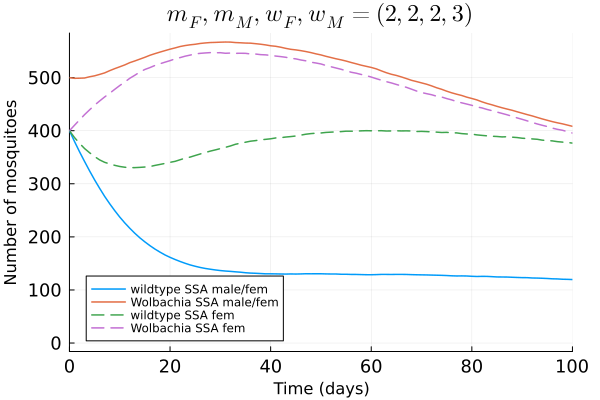

In [ ]:
p=plot(t_start:t_end, vec(Mss), xlabel="Time (days)", ylabel="Number of mosquitoes", title="\$m_F,m_M,w_F,w_M=($(fem_m0),$(male_m0),$(fem_w0),$(male_w0))\$", label="wildtype SSA male/fem", linewidth=1.5)
plot!(t_start:t_end, vec(Wss), label="Wolbachia SSA male/fem", linewidth=1.5)
plot!(t_start:t_end, 2*vec(Mss_f), label="wildtype SSA fem", linestyle=:dash, linewidth=1.5)
plot!(t_start:t_end, 2*vec(Wss_f), label="Wolbachia SSA fem", linestyle=:dash, linewidth=1.5)
#plot!(xlim=(0,100))
plot!(xlabelfont=font(14), ylabelfont=font(14), titlefont=font(16), xtickfont=font(12), ytickfont=font(12), linewidth=1.5)
plot!(right_margin = 5Plots.mm)
#plot!(legend=(0.4,0.7))
#savefig(p, "male_fem_traj_comp_zoom_2223.pdf")
p

In [55]:
# Prepare the data as vectors
time = collect(t_start:t_end)
wildtype_SSA_male_fem = vec(Mss)
wolbachia_SSA_male_fem = vec(Wss)
wildtype_SSA_fem = vec(Mss_f)
wolbachia_SSA_fem = vec(Wss_f)

# Create a DataFrame
df = DataFrame(
    time = time,
    wildtype_SSA_male_fem = wildtype_SSA_male_fem,
    wolbachia_SSA_male_fem = wolbachia_SSA_male_fem,
    wildtype_SSA_fem = wildtype_SSA_fem,
    wolbachia_SSA_fem = wolbachia_SSA_fem
)

# Save to CSV
CSV.write("male_fem_traj_comp_$(fem_m0)$(male_m0)$(fem_w0)$(male_w0).csv", df)

"male_fem_traj_comp_2223.csv"

In [6]:
# Load the data from the CSV file
df = CSV.read("male_fem_traj_comp_$(fem_m0)$(male_m0)$(fem_w0)$(male_w0).csv", DataFrame)

# Extract columns as vectors
time = df.time
Mss = df.wildtype_SSA_male_fem
Wss = df.wolbachia_SSA_male_fem
Mss_f = df.wildtype_SSA_fem
Wss_f = df.wolbachia_SSA_fem

1001-element Vector{Float64}:
 200.0
 205.201
 210.071
 214.852
 219.592
 223.499
 226.978
 230.818
 234.32
 237.964
   ⋮
   0.703
   0.68
   0.676
   0.67
   0.662
   0.644
   0.648
   0.647
   0.616